In [2]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

In [4]:
#shots=pd.read_csv("shots_df.csv")
shots=pd.read_csv("shots_selected_features.csv")
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,472359,0,0,0,0,38.013156,22.249024,0.001169,0
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,546236,0,0,0,1,24.207437,28.131342,0.369600,0
2,2525775934,5590087,1H,17,22,00:17:22.682,1043.682911,88,50,8738,66175,0,0,0,0,23.345235,33.404163,0.019250,0
3,2525776003,5590087,1H,23,31,00:23:31.670,1412.670761,89,50,8738,526355,1,0,0,0,22.627417,33.751379,0.152000,0
4,2525776121,5590087,1H,25,25,00:25:25.953,1526.953456,87,50,6713,54783,1,0,0,0,24.083189,32.995607,0.031020,0


MERGING BOTH DATASETS

In [5]:
import json
import os

def extract_video_timestamps_from_shot_file(filepath):
    file_key = filepath.split("/")[-1].replace(".json", "")
    with open(filepath, 'r') as f:
        data = json.load(f)
    timestamps = [event['videoTimestamp'] for event in data if 'videoTimestamp' in event]
    return {file_key: timestamps}



In [6]:
df = extract_video_timestamps_from_shot_file("shot_pack/shots/644507.json")

In [7]:
def get_closest_tracking_frames_for_shots_with_context(shot_file, tracking_file, prev_frames=2, next_frames=2):
    """
    Extract closest tracking frames for shot timestamps, including previous and next frames around each match.
    
    Args:
        shot_file: Path to the shot JSON file
        tracking_file: Path to the tracking JSONL file
        prev_frames: Number of frames to include before the closest match (default: 2)
        next_frames: Number of frames to include after the closest match (default: 2)
    
    Returns:
        Dictionary with shot timestamps as keys and frame context data as values
    """
    with open(shot_file, 'r') as sf:
        shot_data = json.load(sf)
    
    video_timestamps = [
        str(event['videoTimestamp']) for event in shot_data 
        if 'videoTimestamp' in event and event.get('type', {}).get('primary') == 'shot'
    ]
    
    # First pass: read all tracking frames into memory
    tracking_frames = []
    with open(tracking_file, 'r') as tf:
        for line in tf:
            try:
                frame = json.loads(line)
                ts = frame.get('videoTimestamp') or frame.get('Videotimestamp')
                if ts is not None:
                    tracking_frames.append(frame)
            except json.JSONDecodeError:
                continue
    
    # Sort tracking frames by timestamp for easier context extraction
    tracking_frames.sort(key=lambda x: x.get('videoTimestamp') or x.get('Videotimestamp'))
    
    closest_frames_with_context = {}
    
    # Second pass: find closest matches and extract context
    for shot_ts in video_timestamps:
        shot_timestamp = float(shot_ts)
        min_diff = float('inf')
        closest_index = -1
        
        # Find the closest frame index
        for i, frame in enumerate(tracking_frames):
            frame_ts = frame.get('videoTimestamp') or frame.get('Videotimestamp')
            diff = abs(frame_ts - shot_timestamp)
            if diff < min_diff:
                min_diff = diff
                closest_index = i
        
        if closest_index != -1:
            # Extract previous frames (if available)
            prev_start_idx = max(0, closest_index - prev_frames)
            prev_frames_data = []
            for i in range(prev_start_idx, closest_index):
                frame_info = {
                    'frame': tracking_frames[i],
                    'position_relative_to_closest': i - closest_index,
                    'frame_type': 'previous'
                }
                prev_frames_data.append(frame_info)
            
            # Extract next frames (if available)  
            next_end_idx = min(len(tracking_frames), closest_index + next_frames + 1)
            next_frames_data = []
            for i in range(closest_index + 1, next_end_idx):
                frame_info = {
                    'frame': tracking_frames[i],
                    'position_relative_to_closest': i - closest_index,
                    'frame_type': 'next'
                }
                next_frames_data.append(frame_info)
            
            # Combine all frames for backward compatibility
            all_context_frames = prev_frames_data + [{
                'frame': tracking_frames[closest_index],
                'position_relative_to_closest': 0,
                'frame_type': 'closest',
                'is_closest': True
            }] + next_frames_data
            
            closest_frames_with_context[shot_ts] = {
                'closest_frame': tracking_frames[closest_index],
                'previous_frames': prev_frames_data,
                'next_frames': next_frames_data
            }
    
    return closest_frames_with_context

In [8]:
def get_all_shot_tracking_matches_with_context(shots_dir, tracking_dir, prev_frames=2, next_frames=2, max_files=10):
    """
    Process shot-tracking matches with context frames (limited to first max_files).
    
    Args:
        shots_dir: Directory containing shot JSON files
        tracking_dir: Directory containing tracking JSONL files
        prev_frames: Number of frames to include before each closest match (default: 2)
        next_frames: Number of frames to include after each closest match (default: 2)
        max_files: Maximum number of files to process (default: 10)
    
    Returns:
        Dictionary with match IDs as keys and frame context data as values
    """
    all_matches = {}
    processed_count = 0
    
    # Get sorted list of JSON files to ensure consistent ordering
    json_files = [f for f in os.listdir(shots_dir) if f.endswith('.json')]
    json_files.sort()  # Sort for consistent processing order
    
    for filename in json_files:
        if processed_count >= max_files:
            print(f"Reached maximum file limit ({max_files}). Stopping processing.")
            break
            
        match_id = filename.replace('.json', '')
        shot_path = os.path.join(shots_dir, f"{match_id}.json")
        tracking_path = os.path.join(tracking_dir, f"{match_id}_tracking_data.jsonl")
        
        if os.path.exists(tracking_path):
            result = get_closest_tracking_frames_for_shots_with_context(
                shot_path, tracking_path, prev_frames, next_frames
            )
            all_matches[match_id] = result
            processed_count += 1
            
            print(f"Processed {processed_count}/{max_files}: {match_id}")
        else:
            print(f"Tracking file missing for {match_id}")
    
    print(f"Total matches processed: {processed_count} out of {max_files} requested")
    return all_matches

In [9]:
all_data = get_all_shot_tracking_matches_with_context("shot_pack/shots", "shot_pack/jsonls",5,5,258)

Processed 1/258: 644494
Processed 2/258: 644507
Processed 3/258: 644510
Processed 4/258: 644513
Processed 5/258: 644524
Processed 6/258: 644543
Processed 7/258: 644545
Processed 8/258: 644546
Processed 9/258: 644547
Processed 10/258: 644548
Processed 11/258: 644549
Processed 12/258: 644550
Processed 13/258: 644551
Processed 14/258: 644552
Processed 15/258: 644553
Processed 16/258: 644554
Processed 17/258: 644555
Processed 18/258: 644556
Processed 19/258: 644557
Processed 20/258: 644559
Processed 21/258: 644560
Processed 22/258: 644561
Processed 23/258: 644562
Processed 24/258: 644563
Processed 25/258: 644564
Processed 26/258: 644565
Processed 27/258: 644566
Processed 28/258: 644567
Processed 29/258: 644570
Processed 30/258: 644572
Processed 31/258: 644573
Processed 32/258: 644574
Processed 33/258: 644575
Processed 34/258: 644576
Processed 35/258: 644578
Processed 36/258: 644580
Processed 37/258: 644581
Processed 38/258: 644583
Processed 39/258: 644584
Processed 40/258: 644585
Processed

In [10]:
def extract_match_data_from_directory(directory_path):
    """
    Create a dictionary where keys are match_ids and values are match_data
    from all JSON files in the specified directory.
    
    Args:
        directory_path (str): Path to the directory containing the JSON files
        
    Returns:
        dict: Dictionary with match_id as keys and match_data as values
    """
    match_data_dict = {}
    
    # Check if directory exists
    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Directory '{directory_path}' does not exist")
    
    # Iterate through all files in the directory
    for filename in os.listdir(directory_path):
        file_path = os.path.join(directory_path, filename)
        
        # Skip if it's not a file
        if not os.path.isfile(file_path):
            continue
            
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                # Read the first line which contains the match_data
                first_line = file.readline().strip()
                
                if first_line:
                    # Parse the JSON from the first line
                    data = json.loads(first_line)
                    
                    # Extract all the data (match_data, teams_data, players_data, FPS)
                    if 'match_data' in data:
                        match_id = data['match_data'].get('match_id')
                        
                        if match_id:
                            # Convert match_id to string to ensure consistency
                            match_id_str = str(match_id)
                            # Store the entire first line data (not just match_data)
                            match_data_dict[match_id_str] = data
                        else:
                            print(f"Warning: No match_id found in file '{filename}'")
                    else:
                        print(f"Warning: No match_data found in file '{filename}'")
                        
        except json.JSONDecodeError as e:
            print(f"Error parsing JSON in file '{filename}': {e}")
        except Exception as e:
            print(f"Error reading file '{filename}': {e}")
    
    return match_data_dict

In [11]:
match_info= extract_match_data_from_directory("shot_pack/jsonls")
match_info

{'644645': {'match_data': {'season_data': {'name': 'UCL 2024', 'id': 818378},
   'date': '2024-12-11',
   'match_id': 644645,
   'result': {'home': 0, 'away': 0}},
  'teams_data': {'home': {'name': 'SL Benfica', 'id': 61318},
   'away': {'name': 'Bologna', 'id': 12}},
  'players_data': {'61318': {'1262779': {'number': 1,
     'name': 'Anatolii Trubin',
     'position': 'GK'},
    '1267199': {'number': 3, 'name': 'Alvaro Fernandez', 'position': 'DL'},
    '1528624': {'number': 6, 'name': 'Alexander Bah', 'position': 'DR'},
    '122541': {'number': 30, 'name': 'Nicolas Otamendi', 'position': 'DC'},
    '1339424': {'number': 44, 'name': 'Tomas Araujo', 'position': 'DC'},
    '1156661': {'number': 8, 'name': 'Fredrik Aursnes', 'position': 'MC'},
    '1172508': {'number': 10, 'name': 'Orkun Kokcu', 'position': 'MC'},
    '1261490': {'number': 61, 'name': 'Florentino', 'position': 'DMC'},
    '80742': {'number': 11, 'name': 'Angel Di Maria', 'position': 'FWR'},
    '1158780': {'number': 14, 

In [12]:
# Initialize the new structure
all_data_augmented = {}

# Loop over each match in all_data
for match_id, timestamp_dict in all_data.items():
    all_data_augmented[match_id] = all_data[match_id]

    for timestamp, frame_group in timestamp_dict.items():
        all_data_augmented[match_id][timestamp]["match_info"]= match_info[match_id]



In [13]:
all_data_augmented["644494"]["182.042218"]["match_info"]

{'match_data': {'season_data': {'name': 'UCF 2024', 'id': 817384},
  'date': '2024-11-28',
  'match_id': '644494',
  'result': {'home': 0, 'away': 1}},
 'teams_data': {'home': {'name': 'The New Saints', 'id': 66365},
  'away': {'name': 'Djurgaarden', 'id': 61258}},
 'players_data': {'66365': {'1281528': {'number': 25,
    'name': 'Connor Roberts',
    'position': 'GK'},
   '1171150': {'number': 2, 'name': 'Josh Pask', 'position': 'DC'},
   '43827': {'number': 16, 'name': 'Harrison Mcgahey', 'position': 'DC'},
   '1541716': {'number': 22, 'name': 'Danny Davies', 'position': 'DL'},
   '1169867': {'number': 24, 'name': 'Ash Baker', 'position': 'DR'},
   '1162940': {'number': 10, 'name': 'Daniel Redmond', 'position': 'MC'},
   '1262330': {'number': 14, 'name': 'Daniel Williams', 'position': 'MC'},
   '1423089': {'number': 7, 'name': 'Joshua Daniels', 'position': 'FWR'},
   '1271100': {'number': 9, 'name': 'Declan Mcmanus', 'position': 'FW'},
   '1181037': {'number': 17, 'name': 'Jordan Wil

In [14]:
shots['videoTimestamp'] = shots['videoTimestamp'].astype(str)

In [15]:
# Load the mapping once
with open("shot_pack/mappings/player_event_id_to_tracking_id.json") as f:
    event_to_tracking_map = json.load(f)

In [16]:
# Build lookup: videoTimestamp → full frame info (includes match_info now)
timestamp_lookup = {}
for match in all_data_augmented.values():
    for timestamp, frame_info in match.items():
        timestamp_lookup[timestamp] = frame_info

# Extract frame parts
def extract_frame_part(row, part):
    frame_data = timestamp_lookup.get(row['videoTimestamp'], {})
    return frame_data.get(part)

# Assign all frame-related columns
shots['closest_frame'] = shots.apply(lambda row: extract_frame_part(row, 'closest_frame'), axis=1)
shots['previous_frames'] = shots.apply(lambda row: extract_frame_part(row, 'previous_frames'), axis=1)
shots['next_frames'] = shots.apply(lambda row: extract_frame_part(row, 'next_frames'), axis=1)

# Assign match_info from the frame-level "match_info" key
shots['match_info'] = shots['videoTimestamp'].map(lambda ts: timestamp_lookup.get(ts, {}).get('match_info'))


COMPUTE R AND ANGLE

In [17]:
def compute_shot_to_goal_distance(row, event_to_tracking_map):
    frame = row['closest_frame']
    players_data = row['match_info'].get('players_data', {})
    frame_data = frame['data']
    
    if len(frame_data) != 2:
        return np.nan

    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]

    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None

    if tracking_id and tracking_id != 'None':
        for team in [team0, team1]:
            for player in team:
                if str(player['id']) == tracking_id:
                    shooter_coords = (player['x'], player['y'])
                    break
            if shooter_coords:
                break

    if not shooter_coords:
        return np.nan  # shooter not found in tracking

    shooter_team_id = str(row['team_id'])
    shooter_team = team0 if team0_id == shooter_team_id else team1

    # Try to find GK
    gk_coords = None
    for p in shooter_team:
        pid = str(p['id'])
        if pid in players_data.get(shooter_team_id, {}) and players_data[shooter_team_id][pid].get('position') == 'GK':
            gk_coords = (p['x'], p['y'])
            break

    if gk_coords:
        attack_right = shooter_coords[0] > gk_coords[0]
    else:
        attack_right = shooter_coords[0] > 52.5

    goal_x = 105 if attack_right else 0
    goal_y = 34  # center vertically

    # Euclidean distance
    dx = shooter_coords[0] - goal_x
    dy = shooter_coords[1] - goal_y
    return np.sqrt(dx**2 + dy**2)


In [18]:
shots['R'] = shots.apply(lambda row: compute_shot_to_goal_distance(row, event_to_tracking_map), axis=1)

In [19]:
def compute_goal_angle(row, event_to_tracking_map):
    frame = row['closest_frame']
    players_data = row['match_info'].get('players_data', {})
    frame_data = frame['data']

    if len(frame_data) != 2:
        return np.nan

    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]

    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None

    if tracking_id and tracking_id != 'None':
        for team in [team0, team1]:
            for player in team:
                if str(player['id']) == tracking_id:
                    shooter_coords = np.array([player['x'], player['y']])
                    break
            if shooter_coords is not None:
                break

    if shooter_coords is None:
        return np.nan

    shooter_team_id = str(row['team_id'])
    shooter_team = team0 if team0_id == shooter_team_id else team1

    # Find GK
    gk_coords = None
    for p in shooter_team:
        pid = str(p['id'])
        if pid in players_data.get(shooter_team_id, {}) and players_data[shooter_team_id][pid].get('position') == 'GK':
            gk_coords = np.array([p['x'], p['y']])
            break

    if gk_coords is not None:
        attack_right = shooter_coords[0] > gk_coords[0]
    else:
        attack_right = shooter_coords[0] > 52.5

    goal_x = 105 if attack_right else 0
    goal_y = 34
    goal_center = np.array([goal_x, goal_y])

    shot_vec = goal_center - shooter_coords
    ref_vec = np.array([1, 0]) if attack_right else np.array([-1, 0])

    dot = np.dot(shot_vec, ref_vec)
    norm = np.linalg.norm(shot_vec) * np.linalg.norm(ref_vec)
    angle_rad = np.arccos(dot / norm) if norm > 0 else 0.0
    return np.degrees(angle_rad)


In [20]:
shots['goal_angle'] = shots.apply(lambda row: compute_goal_angle(row, event_to_tracking_map), axis=1)

In [21]:
import json
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Arc

# Load the mapping once
with open("shot_pack/mappings/player_event_id_to_tracking_id.json") as f:
    event_to_tracking_map = json.load(f)

def plot_closest_frame_for_shot(row):
    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})
    frame_data = frame['data']

    home_team_id = str(match_info['teams_data']['home']['id'])
    away_team_id = str(match_info['teams_data']['away']['id'])
    home_team = match_info['teams_data']['home']['name']
    away_team = match_info['teams_data']['away']['name']
    season = match_info['match_data']['season_data']['name']
    match_title = f"{home_team} vs {away_team} ({season})"

    if len(frame_data) != 2:
        print("Invalid frame data (not 2 teams)")
        return
    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]
    ball = frame.get('ball')

    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(8, 6))
    fig.suptitle(match_title, fontsize=14, fontweight='bold')

    def get_colors(team_players, team_id):
        colors = []
        for p in team_players:
            pid = str(p['id'])
            if team_id in players_data and pid in players_data[team_id]:
                role = players_data[team_id][pid].get('position', '')
                if role == 'GK':
                    colors.append('green')
                else:
                    colors.append('blue' if team_id == home_team_id else 'red')
            else:
                colors.append('blue' if team_id == home_team_id else 'red')
        return colors

    pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                  c=get_colors(team0, team0_id), s=80, edgecolors='black', alpha=0.8)
    pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                  c=get_colors(team1, team1_id), s=80, edgecolors='black', alpha=0.8)

    if isinstance(ball, (list, tuple)) and len(ball) >= 2 and None not in ball:
        pitch.scatter(ball[0], ball[1], ax=ax, color='white', edgecolors='black', s=150, zorder=5)

    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None

    if tracking_id and tracking_id != 'None':
        for team in [team0, team1]:
            for player in team:
                if str(player['id']) == tracking_id:
                    shooter_coords = np.array([player['x'], player['y']])
                    pitch.scatter(*shooter_coords, ax=ax,
                                  color='black', s=120, edgecolors='white', zorder=6, label='Shooter')
                    break
            if shooter_coords is not None:
                break

    if shooter_coords is not None:
        shooter_team_id = str(row['team_id'])
        shooter_team = team0 if team0_id == shooter_team_id else team1

        # Find GK
        gk_coords = None
        for p in shooter_team:
            pid = str(p['id'])
            if pid in players_data.get(shooter_team_id, {}) and players_data[shooter_team_id][pid].get('position') == 'GK':
                gk_coords = np.array([p['x'], p['y']])
                break

        # Determine attack direction
        if gk_coords is not None:
            attack_right = shooter_coords[0] > gk_coords[0]
        else:
            attack_right = shooter_coords[0] > 52.5

        # Goal and posts
        goal_x = 105 if attack_right else 0
        goal_y = 34
        left_post = np.array([goal_x, goal_y - 3.66])
        right_post = np.array([goal_x, goal_y + 3.66])

        # R arrow to goal center
        pitch.annotate('', xy=(goal_x, goal_y), xytext=shooter_coords,
                       arrowprops=dict(arrowstyle='->', color='black', lw=2), ax=ax)

        # Draw angle arc
        vec_left = left_post - shooter_coords
        vec_right = right_post - shooter_coords

        angle_rad = np.arccos(
            np.dot(vec_left, vec_right) /
            (np.linalg.norm(vec_left) * np.linalg.norm(vec_right))
        )
        angle_deg = np.degrees(angle_rad)

        # Arc from vec_left to vec_right
        start_angle = np.degrees(np.arctan2(vec_left[1], vec_left[0]))
        arc = Arc(
            xy=shooter_coords,
            width=10, height=10,  # radius of arc
            angle=0,
            theta1=start_angle,
            theta2=start_angle + angle_deg,
            color='yellow',
            lw=2
        )
        ax.add_patch(arc)

    # Title
    timestamp = frame.get('Videotimestamp', None)
    time_str = f"{timestamp:.2f}s" if timestamp else "Unknown Time"
    ax.set_title(f"Shot Frame • {time_str}", fontsize=12, color='darkred')

    plt.tight_layout()
    plt.show()


/Users/diego/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


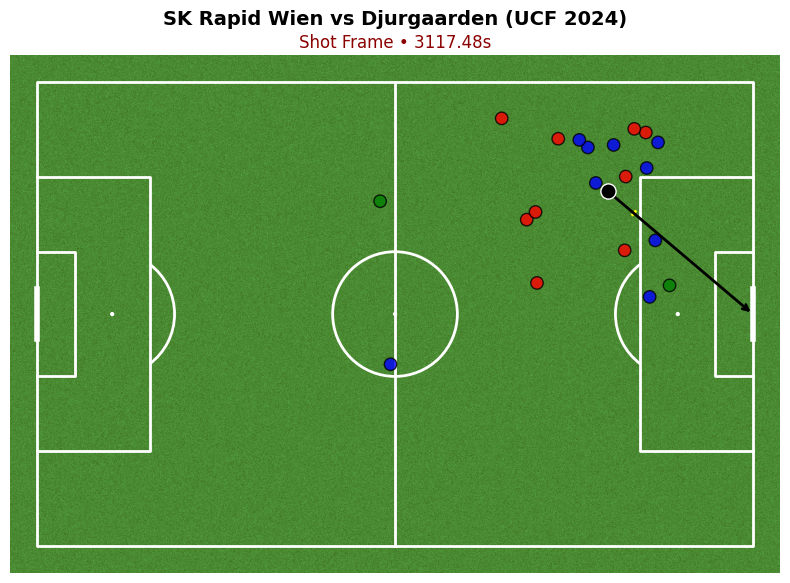

In [22]:
plot_closest_frame_for_shot(shots.iloc[8])

COMPUTE DDL AND PLOT IT

In [23]:
def get_goal_facing_cone(row, event_to_tracking_map):
    frame = row['closest_frame']
    players_data = row['match_info'].get('players_data', {})
    frame_data = frame['data']

    if len(frame_data) != 2:
        return None

    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]

    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None

    if tracking_id and tracking_id != 'None':
        for team in [team0, team1]:
            for player in team:
                if str(player['id']) == tracking_id:
                    shooter_coords = np.array([player['x'], player['y']])
                    break
            if shooter_coords is not None:
                break

    if shooter_coords is None:
        return None

    shooter_team_id = str(row['team_id'])
    shooter_team = team0 if team0_id == shooter_team_id else team1

    # Determine direction from GK
    gk_coords = None
    for p in shooter_team:
        pid = str(p['id'])
        if pid in players_data.get(shooter_team_id, {}) and players_data[shooter_team_id][pid].get('position') == 'GK':
            gk_coords = np.array([p['x'], p['y']])
            break

    attack_right = shooter_coords[0] > gk_coords[0] if gk_coords is not None else shooter_coords[0] > 52.5

    # Goalposts
    goal_x = 105 if attack_right else 0
    goal_y = 34
    left_post = np.array([goal_x, goal_y - 3.66])
    right_post = np.array([goal_x, goal_y + 3.66])

    vec_left = left_post - shooter_coords
    vec_right = right_post - shooter_coords

    return {
        "shooter": shooter_coords,
        "vec_left": vec_left,
        "vec_right": vec_right,
        "goal_x": goal_x,
        "goal_y": goal_y
    }


In [24]:
def plot_frame_with_goal_cone(row, event_to_tracking_map):
    cone = get_goal_facing_cone(row, event_to_tracking_map)
    if cone is None:
        print("Could not compute cone.")
        return

    shooter_coords = cone['shooter']
    left_vec = cone['vec_left']
    right_vec = cone['vec_right']
    goal_x, goal_y = cone['goal_x'], cone['goal_y']

    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})
    frame_data = frame['data']

    home_team_id = str(match_info['teams_data']['home']['id'])
    away_team_id = str(match_info['teams_data']['away']['id'])
    home_team = match_info['teams_data']['home']['name']
    away_team = match_info['teams_data']['away']['name']
    season = match_info['match_data']['season_data']['name']
    match_title = f"{home_team} vs {away_team} ({season})"

    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]
    ball = frame.get('ball')

    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(8, 6))
    fig.suptitle(match_title, fontsize=14, fontweight='bold')

    def get_colors(team_players, team_id):
        colors = []
        for p in team_players:
            pid = str(p['id'])
            if team_id in players_data and pid in players_data[team_id]:
                role = players_data[team_id][pid].get('position', '')
                if role == 'GK':
                    colors.append('green')
                else:
                    colors.append('blue' if team_id == home_team_id else 'red')
            else:
                colors.append('blue' if team_id == home_team_id else 'red')
        return colors

    pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                  c=get_colors(team0, team0_id), s=80, edgecolors='black', alpha=0.8)
    pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                  c=get_colors(team1, team1_id), s=80, edgecolors='black', alpha=0.8)

    if isinstance(ball, (list, tuple)) and len(ball) >= 2 and None not in ball:
        pitch.scatter(ball[0], ball[1], ax=ax, color='white', edgecolors='black', s=150, zorder=5)

    # Shooter and cone lines
    pitch.scatter(*shooter_coords, ax=ax, color='black', s=120, edgecolors='white', zorder=6)
    pitch.lines(shooter_coords[0], shooter_coords[1],
            shooter_coords[0] + left_vec[0], shooter_coords[1] + left_vec[1],
            color='yellow', ax=ax, lw=2)
    pitch.lines(shooter_coords[0], shooter_coords[1],
            shooter_coords[0] + right_vec[0], shooter_coords[1] + right_vec[1],
            color='yellow', ax=ax, lw=2)


    # Title
    timestamp = frame.get('Videotimestamp', None)
    time_str = f"{timestamp:.2f}s" if timestamp else "Unknown Time"
    ax.set_title(f"Shot Frame • {time_str}", fontsize=12, color='darkred')

    plt.tight_layout()
    plt.show()


In [25]:
def compute_ddi(row, event_to_tracking_map):
    cone = get_goal_facing_cone(row, event_to_tracking_map)
    if cone is None:
        return np.nan

    shooter = cone['shooter']
    vec_left = np.append(cone['vec_left'], 0)   # convert to 3D
    vec_right = np.append(cone['vec_right'], 0)

    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})
    frame_data = frame['data']

    if len(frame_data) != 2:
        return np.nan

    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]

    all_players = team0 + team1
    shooter_tracking_id = str(event_to_tracking_map.get(str(row['player_id'])))
    count = 0

    for player in all_players:
        pid = str(player['id'])

        if pid == shooter_tracking_id:
            continue

        # Determine team and role
        team_id = team0_id if player in team0 else team1_id
        if pid not in players_data.get(team_id, {}):
            continue
        if players_data[team_id][pid].get('position') == 'GK':
            continue

        pos = np.array([player['x'], player['y']])
        vec_to_player = np.append(pos - shooter, 0)

        distance = np.linalg.norm(vec_to_player[:2])
        if distance > 5:
            continue

        # Cross product test
        cross1 = np.cross(vec_left, vec_to_player)[2]
        cross2 = np.cross(vec_to_player, vec_right)[2]

        if cross1 >= 0 and cross2 >= 0:
            count += 1

    return count


In [26]:
shots['DDI'] = shots.apply(lambda row: compute_ddi(row, event_to_tracking_map), axis=1)
shots[shots["DDI"]>1].head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal,closest_frame,previous_frames,next_frames,match_info,R,goal_angle,DDI
15,2525777866,5590087,2H,52,3,00:52:03.353,3624.353544,86,30,8738,590583,0,0,0,0,19.416488,49.123908,0.06940,0,"{'data': {'61258': [{'x': 89.3, 'y': 44.59, 'v...","[{'frame': {'data': {'61258': [{'x': 88.29, 'y...","[{'frame': {'data': {'61258': [{'x': 89.42, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,21.839435,40.040705,2.0
299,2462401597,5589316,1H,16,19,00:16:19.564,980.564946,90,48,4492,403273,0,0,0,0,20.518285,38.453709,0.24140,0,"{'data': {'7958': [{'x': 96.99, 'y': 26.36, 'v...","[{'frame': {'data': {'7958': [{'x': 97.55, 'y'...","[{'frame': {'data': {'7958': [{'x': 96.9, 'y':...",{'match_data': {'season_data': {'name': 'UEL 2...,9.150847,8.927056,2.0
381,2439755087,5589299,1H,47,27,00:47:27.163,2849.163679,99,49,5120,833655,0,0,0,0,16.155494,30.963757,0.59410,0,"{'data': {'62559': [{'x': 48.88, 'y': 55.4, 'v...","[{'frame': {'data': {'62559': [{'x': 49.24, 'y...","[{'frame': {'data': {'62559': [{'x': 48.8, 'y'...",{'match_data': {'season_data': {'name': 'UEL 2...,5.825298,38.798055,2.0
417,2310723749,5588914,2H,89,18,01:29:18.912,5373.912099,89,53,3159,443324,1,0,0,0,24.839485,28.249735,0.06806,0,"{'data': {'39': [{'x': 53.34, 'y': 26.87, 'vis...","[{'frame': {'data': {'39': [{'x': 53.26, 'y': ...","[{'frame': {'data': {'39': [{'x': 53.34, 'y': ...",{'match_data': {'season_data': {'name': 'UCL 2...,8.952877,7.315525,4.0
444,2476189899,5589082,1H,11,29,00:11:29.014,690.014925,99,53,3767,286390,0,0,0,0,19.924859,18.868999,0.63450,1,"{'data': {'7186': [{'x': 16.01, 'y': 39.92, 'v...","[{'frame': {'data': {'7186': [{'x': 16.47, 'y'...","[{'frame': {'data': {'7186': [{'x': 15.86, 'y'...",{'match_data': {'season_data': {'name': 'UCL 2...,1.880957,8.560890,3.0


In [33]:
def count_players_in_cone(row, event_to_tracking_map):
    cone = get_goal_facing_cone(row, event_to_tracking_map)
    if cone is None:
        return np.nan

    shooter = cone['shooter']
    vec_left = np.append(cone['vec_left'], 0)   # 3D
    vec_right = np.append(cone['vec_right'], 0)

    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})
    frame_data = frame['data']

    if len(frame_data) != 2:
        return np.nan

    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]
    all_players = team0 + team1

    shooter_tracking_id = str(event_to_tracking_map.get(str(row['player_id'])))
    count = 0

    for player in all_players:
        pid = str(player['id'])

        if pid == shooter_tracking_id:
            continue  # ignorar al tirador

        team_id = team0_id if player in team0 else team1_id
        if pid not in players_data.get(team_id, {}):
            continue
        if players_data[team_id][pid].get('position') == 'GK':
            continue  # ignorar portero

        pos = np.array([player['x'], player['y']])
        vec_to_player = np.append(pos - shooter, 0)

        # Comprobar si está dentro del cono
        cross1 = np.cross(vec_left, vec_to_player)[2]
        cross2 = np.cross(vec_to_player, vec_right)[2]

        if cross1 >= 0 and cross2 >= 0:
            count += 1

    return count


In [34]:
shots['DDI_complete'] = shots.apply(lambda row: count_players_in_cone(row, event_to_tracking_map), axis=1)


In [107]:
shots.head(10)

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal,closest_frame,previous_frames,next_frames,match_info,R,goal_angle,DDI,DDI_complete,gk_is_valid
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,472359,0,0,0,0,38.013156,22.249024,0.001169,0,"{'data': {'61258': [{'x': 81.4, 'y': 26.97, 'v...","[{'frame': {'data': {'61258': [{'x': 80.72, 'y...","[{'frame': {'data': {'61258': [{'x': 81.36, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,24.624803,16.587813,0.0,2.0,True
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,546236,0,0,0,1,24.207437,28.131342,0.369600,0,"{'data': {'61258': [{'x': 78.15, 'y': 34.96, '...","[{'frame': {'data': {'61258': [{'x': 77.51, 'y...","[{'frame': {'data': {'61258': [{'x': 78.26, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.127209,14.517517,0.0,0.0,True
2,2525775934,5590087,1H,17,22,00:17:22.682,1043.682911,88,50,8738,66175,0,0,0,0,23.345235,33.404163,0.019250,0,"{'data': {'61258': [{'x': 4.98, 'y': 28.52, 'v...","[{'frame': {'data': {'61258': [{'x': 3.66, 'y'...","[{'frame': {'data': {'61258': [{'x': 5.32, 'y'...",{'match_data': {'season_data': {'name': 'UCF 2...,13.676728,10.447233,0.0,1.0,False
3,2525776003,5590087,1H,23,31,00:23:31.670,1412.670761,89,50,8738,526355,1,0,0,0,22.627417,33.751379,0.152000,0,"{'data': {'61258': [{'x': 13.4, 'y': 27.82, 'v...","[{'frame': {'data': {'61258': [{'x': 13.06, 'y...","[{'frame': {'data': {'61258': [{'x': 13.47, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.396290,5.462242,1.0,2.0,False
4,2525776121,5590087,1H,25,25,00:25:25.953,1526.953456,87,50,6713,54783,1,0,0,0,24.083189,32.995607,0.031020,0,"{'data': {'61258': [{'x': 87.46, 'y': 31.86, '...","[{'frame': {'data': {'61258': [{'x': 87.12, 'y...","[{'frame': {'data': {'61258': [{'x': 87.48, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,6.845144,33.318625,0.0,0.0,True
5,2525776141,5590087,1H,34,14,00:34:14.914,2055.914651,74,71,8738,66175,0,0,0,0,48.270074,13.934294,0.002932,0,"{'data': {'61258': [{'x': 14.57, 'y': 35.38, '...","[{'frame': {'data': {'61258': [{'x': 12.46, 'y...","[{'frame': {'data': {'61258': [{'x': 14.98, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,25.123744,15.585148,0.0,0.0,False
6,2525776409,5590087,1H,48,20,00:48:20.668,2901.668593,89,56,6713,627932,0,0,0,0,27.202941,23.606569,0.292600,0,"{'data': {'61258': [{'x': 55.87, 'y': 28.11, '...","[{'frame': {'data': {'61258': [{'x': 55.52, 'y...","[{'frame': {'data': {'61258': [{'x': 55.92, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.207084,19.874835,1.0,2.0,True
7,2525776343,5590087,1H,50,59,00:50:59.666,3060.666626,87,58,8738,66175,0,0,0,0,30.000000,21.583969,0.015760,0,"{'data': {'61258': [{'x': 12.77, 'y': 26.38, '...","[{'frame': {'data': {'61258': [{'x': 14.41, 'y...","[{'frame': {'data': {'61258': [{'x': 12.43, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,30.875197,3.100569,0.0,1.0,False
8,2525776442,5590087,1H,51,56,00:51:56.433,3117.433292,73,29,6713,627932,0,0,0,0,32.388269,30.754394,0.004444,0,"{'data': {'61258': [{'x': 76.46, 'y': 59.73, '...","[{'frame': {'data': {'61258': [{'x': 76.47, 'y...","[{'frame': {'data': {'61258': [{'x': 76.1, 'y'...",{'match_data': {'season_data': {'name': 'UCF 2...,27.869482,40.284648,0.0,0.0,True
9,2525776489,5590087,2H,46,54,00:46:54.095,3315.095036,94,28,6713,54783,0,0,0,0,12.529964,69.001281,0.026520,0,"{'data': {'61258': [{'x': 31.2, 'y': 20.4, 'vi...","[{'frame': {'data': {'61258': [{'x': 33.89, 'y...","[{'frame': {'data': {'61258': [{'x': 30.66, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,18.268424,61.667381,0.0,0.0,True


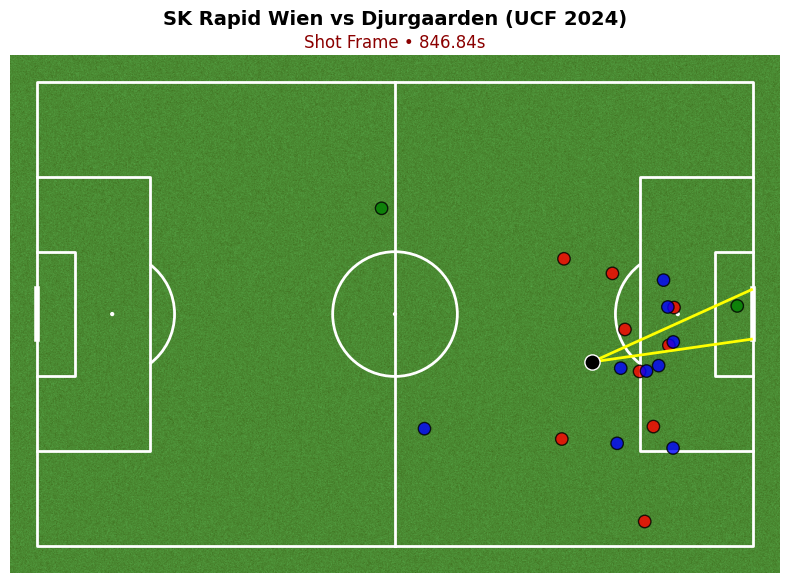

In [109]:
plot_frame_with_goal_cone(shots.iloc[0], event_to_tracking_map)

GOALKEEPER VARIABLE

In [28]:
def plot_all_frames_for_shot(row):
    all_frames = []
    frame_types = []

    for prev_frame in row['previous_frames']:
        all_frames.append(prev_frame['frame'])
        frame_types.append(f"Previous ({prev_frame['position_relative_to_closest']:+d})")

    all_frames.append(row['closest_frame'])
    frame_types.append("CLOSEST (Shot)")

    for next_frame in row['next_frames']:
        all_frames.append(next_frame['frame'])
        frame_types.append(f"Next ({next_frame['position_relative_to_closest']:+d})")

    if not all_frames:
        print("No frames to plot.")
        return

    match_info = row['match_info']
    players_data = match_info['players_data']
    home_team_id = str(match_info['teams_data']['home']['id'])
    away_team_id = str(match_info['teams_data']['away']['id'])
    home_team = match_info['teams_data']['home']['name']
    away_team = match_info['teams_data']['away']['name']
    season = match_info['match_data']['season_data']['name']
    match_title = f"{home_team} vs {away_team} {season}"

    num_frames = len(all_frames)
    rows, cols = (1, num_frames) if num_frames <= 3 else (2, (num_frames + 1) // 2)
    figsize = (6 * cols, 6 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    fig.suptitle(match_title, fontsize=16, fontweight='bold', y=0.98)

    if num_frames == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes
    else:
        axes = axes.flatten()

    # Extract shooter and GK coordinates once from closest_frame
    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None
    gk_coords = None

    for team_players in row['closest_frame']['data'].values():
        for player in team_players:
            pid = str(player['id'])
            if pid == tracking_id:
                shooter_coords = np.array([player['x'], player['y']])
            team_id = str(row['team_id'])
            if pid in players_data.get(team_id, {}) and players_data[team_id][pid].get('position') == 'GK':
                gk_coords = np.array([player['x'], player['y']])

    attack_right = shooter_coords[0] > gk_coords[0] if gk_coords is not None else shooter_coords[0] > 52.5
    goal_x = 105 if attack_right else 0
    goal_y = 34
    left_post = np.array([goal_x, goal_y - 3.66])
    right_post = np.array([goal_x, goal_y + 3.66])

    for i, (frame, frame_type) in enumerate(zip(all_frames, frame_types)):
        ax = axes[i]
        team_ids = list(frame['data'].keys())
        if len(team_ids) != 2:
            ax.text(0.5, 0.5, f"Invalid frame data\n{frame_type}",
                    ha='center', va='center', transform=ax.transAxes)
            continue

        team0_id, team1_id = team_ids
        team0 = frame['data'][team0_id]
        team1 = frame['data'][team1_id]
        ball = frame.get('ball', None)

        pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                      pitch_color='grass', line_color='white')
        pitch.draw(ax=ax)

        def get_player_colors(team_players, team_id):
            colors = []
            for player in team_players:
                player_id = str(player['id'])
                if team_id in players_data and player_id in players_data[team_id]:
                    position = players_data[team_id][player_id]['position']
                    if position == 'GK':
                        colors.append('yellow')
                    else:
                        colors.append('blue' if team_id == home_team_id else 'red')
                else:
                    colors.append('blue' if team_id == home_team_id else 'red')
            return colors

        team0_colors = get_player_colors(team0, team0_id)
        team1_colors = get_player_colors(team1, team1_id)

        pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                      c=team0_colors, s=80, edgecolors='black', alpha=0.8)
        pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                      c=team1_colors, s=80, edgecolors='black', alpha=0.8)

        if ball and ball[0] is not None and ball[1] is not None:
            pitch.scatter(ball[0], ball[1], ax=ax, color='white', edgecolors='black', s=150)

        if shooter_coords is not None:
            pitch.scatter(*shooter_coords, ax=ax, color='black', s=120, edgecolors='white', zorder=6)
            pitch.annotate('', xy=(goal_x, goal_y), xytext=shooter_coords,
                           arrowprops=dict(arrowstyle='->', color='black', lw=2), ax=ax)

            vec_left = left_post - shooter_coords
            vec_right = right_post - shooter_coords

            angle_rad = np.arccos(
                np.dot(vec_left, vec_right) /
                (np.linalg.norm(vec_left) * np.linalg.norm(vec_right))
            )
            angle_deg = np.degrees(angle_rad)

            start_angle = np.degrees(np.arctan2(vec_left[1], vec_left[0]))
            arc = Arc(xy=shooter_coords, width=10, height=10, angle=0,
                      theta1=start_angle, theta2=start_angle + angle_deg,
                      color='yellow', lw=2)
            ax.add_patch(arc)

        timestamp = frame.get('videoTimestamp') or frame.get('Videotimestamp')
        title_color = 'red' if 'CLOSEST' in frame_type else 'black'
        ax.set_title(f"{frame_type}\nTime: {timestamp:.2f}s" if timestamp else frame_type,
                     fontsize=12, fontweight='bold' if 'CLOSEST' in frame_type else 'normal',
                     color=title_color)

    for i in range(num_frames, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

In [195]:
def is_gk_in_target_area(row, event_to_tracking_map, debug=False):
    """
    Check if the goalkeeper is positioned in the target goal area (the goal being shot at).
    Args:
        row: DataFrame row containing shot data with closest_frame and match_info
        event_to_tracking_map: Dictionary mapping event player IDs to tracking IDs
    Returns:
        bool: True if GK is in target goal area, False otherwise, np.nan if GK/shooter not found
    """
    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})
    frame_data = frame['data']
    
    if len(frame_data) != 2:
        return np.nan
    
    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]
    
    # Find shooter coordinates
    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None
    gk_coords = None
    
    # Extract shooter and GK coordinates from all players
    all_players = team0 + team1
    
    # First pass: find shooter
    for player in all_players:
        pid = str(player['id'])
        if pid == tracking_id:
            shooter_coords = np.array([player['x'], player['y']])
            break
    
    # If shooter not found, return NaN
    if shooter_coords is None:
        if debug:
            print(f"Shooter not found. tracking_id: {tracking_id}, available players: {[str(p['id']) for p in all_players]}")
        return np.nan
    
    # Determine attack direction based on shooter position
    attack_right = shooter_coords[0] > 52.5
    target_goal_x = 105 if attack_right else 0
    
    # Second pass: find the goalkeeper closest to the target goal
    closest_gk_distance = float('inf')
    
    for player in all_players:
        pid = str(player['id'])
        
        # Check if this player is a GK in either team
        is_gk = False
        for team_id in [team0_id, team1_id]:
            if pid in players_data.get(team_id, {}) and players_data[team_id][pid].get('position') == 'GK':
                is_gk = True
                break
        
        if is_gk:
            potential_gk_coords = np.array([player['x'], player['y']])
            gk_distance_to_target = abs(potential_gk_coords[0] - target_goal_x)
            
            # Keep the GK closest to the target goal
            if gk_distance_to_target < closest_gk_distance:
                closest_gk_distance = gk_distance_to_target
                gk_coords = potential_gk_coords
    
    if shooter_coords is None or gk_coords is None:
        if debug:
            print(f"Missing data - Shooter found: {shooter_coords is not None}, GK found: {gk_coords is not None}")
            if gk_coords is None:
                gk_positions = []
                for team_id in [team0_id, team1_id]:
                    for pid, player_info in players_data.get(team_id, {}).items():
                        if player_info.get('position') == 'GK':
                            gk_positions.append(f"Team {team_id}: Player {pid}")
                print(f"Available GKs in players_data: {gk_positions}")
        return np.nan
    
    # Determine attack direction and target goal
    attack_right = shooter_coords[0] > 52.5
    target_goal_x = 105 if attack_right else 0
    goal_center_y = 34  # Center of goal (average of 14.3 and 53.7)
    
    # Define goal area boundaries based on penalty area coordinates provided
    # Using penalty area dimensions: 17.9m depth, y-range from 14.3 to 53.7
    penalty_area_depth = 17.9
    penalty_area_y_min = 14.3
    penalty_area_y_max = 53.7
    
    if target_goal_x == 105:  # Right goal
        area_x_min = 105 - penalty_area_depth  # 87.1
        area_x_max = 105
    else:  # Left goal (x=0)
        area_x_min = 0
        area_x_max = penalty_area_depth  # 17.9
    
    area_y_min = penalty_area_y_min
    area_y_max = penalty_area_y_max
    
    # Check if GK is within the target goal area
    gk_x, gk_y = gk_coords
    is_in_target_area = (area_x_min <= gk_x <= area_x_max and
                        area_y_min <= gk_y <= area_y_max)
    
    return is_in_target_area

In [208]:
shots['gk_is_valid'] = shots.apply(lambda row: is_gk_in_target_area(row,event_to_tracking_map), axis=1)
shots.head(20)

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal,closest_frame,previous_frames,next_frames,match_info,R,goal_angle,DDI,DDI_complete,gk_is_valid,gk_in_target_area
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,472359,0,0,0,0,38.013156,22.249024,0.001169,0,"{'data': {'61258': [{'x': 81.4, 'y': 26.97, 'v...","[{'frame': {'data': {'61258': [{'x': 80.72, 'y...","[{'frame': {'data': {'61258': [{'x': 81.36, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,24.624803,16.587813,0.0,2.0,True,False
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,546236,0,0,0,1,24.207437,28.131342,0.369600,0,"{'data': {'61258': [{'x': 78.15, 'y': 34.96, '...","[{'frame': {'data': {'61258': [{'x': 77.51, 'y...","[{'frame': {'data': {'61258': [{'x': 78.26, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.127209,14.517517,0.0,0.0,True,False
2,2525775934,5590087,1H,17,22,00:17:22.682,1043.682911,88,50,8738,66175,0,0,0,0,23.345235,33.404163,0.019250,0,"{'data': {'61258': [{'x': 4.98, 'y': 28.52, 'v...","[{'frame': {'data': {'61258': [{'x': 3.66, 'y'...","[{'frame': {'data': {'61258': [{'x': 5.32, 'y'...",{'match_data': {'season_data': {'name': 'UCF 2...,13.676728,10.447233,0.0,1.0,False,False
3,2525776003,5590087,1H,23,31,00:23:31.670,1412.670761,89,50,8738,526355,1,0,0,0,22.627417,33.751379,0.152000,0,"{'data': {'61258': [{'x': 13.4, 'y': 27.82, 'v...","[{'frame': {'data': {'61258': [{'x': 13.06, 'y...","[{'frame': {'data': {'61258': [{'x': 13.47, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.396290,5.462242,1.0,2.0,True,True
4,2525776121,5590087,1H,25,25,00:25:25.953,1526.953456,87,50,6713,54783,1,0,0,0,24.083189,32.995607,0.031020,0,"{'data': {'61258': [{'x': 87.46, 'y': 31.86, '...","[{'frame': {'data': {'61258': [{'x': 87.12, 'y...","[{'frame': {'data': {'61258': [{'x': 87.48, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,6.845144,33.318625,0.0,0.0,True,False
5,2525776141,5590087,1H,34,14,00:34:14.914,2055.914651,74,71,8738,66175,0,0,0,0,48.270074,13.934294,0.002932,0,"{'data': {'61258': [{'x': 14.57, 'y': 35.38, '...","[{'frame': {'data': {'61258': [{'x': 12.46, 'y...","[{'frame': {'data': {'61258': [{'x': 14.98, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,25.123744,15.585148,0.0,0.0,False,False
6,2525776409,5590087,1H,48,20,00:48:20.668,2901.668593,89,56,6713,627932,0,0,0,0,27.202941,23.606569,0.292600,0,"{'data': {'61258': [{'x': 55.87, 'y': 28.11, '...","[{'frame': {'data': {'61258': [{'x': 55.52, 'y...","[{'frame': {'data': {'61258': [{'x': 55.92, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.207084,19.874835,1.0,2.0,True,False
7,2525776343,5590087,1H,50,59,00:50:59.666,3060.666626,87,58,8738,66175,0,0,0,0,30.000000,21.583969,0.015760,0,"{'data': {'61258': [{'x': 12.77, 'y': 26.38, '...","[{'frame': {'data': {'61258': [{'x': 14.41, 'y...","[{'frame': {'data': {'61258': [{'x': 12.43, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,30.875197,3.100569,0.0,1.0,True,True
8,2525776442,5590087,1H,51,56,00:51:56.433,3117.433292,73,29,6713,627932,0,0,0,0,32.388269,30.754394,0.004444,0,"{'data': {'61258': [{'x': 76.46, 'y': 59.73, '...","[{'frame': {'data': {'61258': [{'x': 76.47, 'y...","[{'frame': {'data': {'61258': [{'x': 76.1, 'y'...",{'match_data': {'season_data': {'name': 'UCF 2...,27.869482,40.284648,0.0,0.0,True,False
9,2525776489,5590087,2H,46,54,00:46:54.095,3315.095036,94,28,6713,54783,0,0,0,0,12.529964,69.001281,0.026520,0,"{'data': {'61258': [{'x': 31.2, 'y': 20.4, 'vi...","[{'frame': {'data': {'61258': [{'x': 33.89, 'y...","[{'frame': {'data': {'61258': [{'x': 30.66, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,18.268424,61.667381,0.0,0.0,True,False


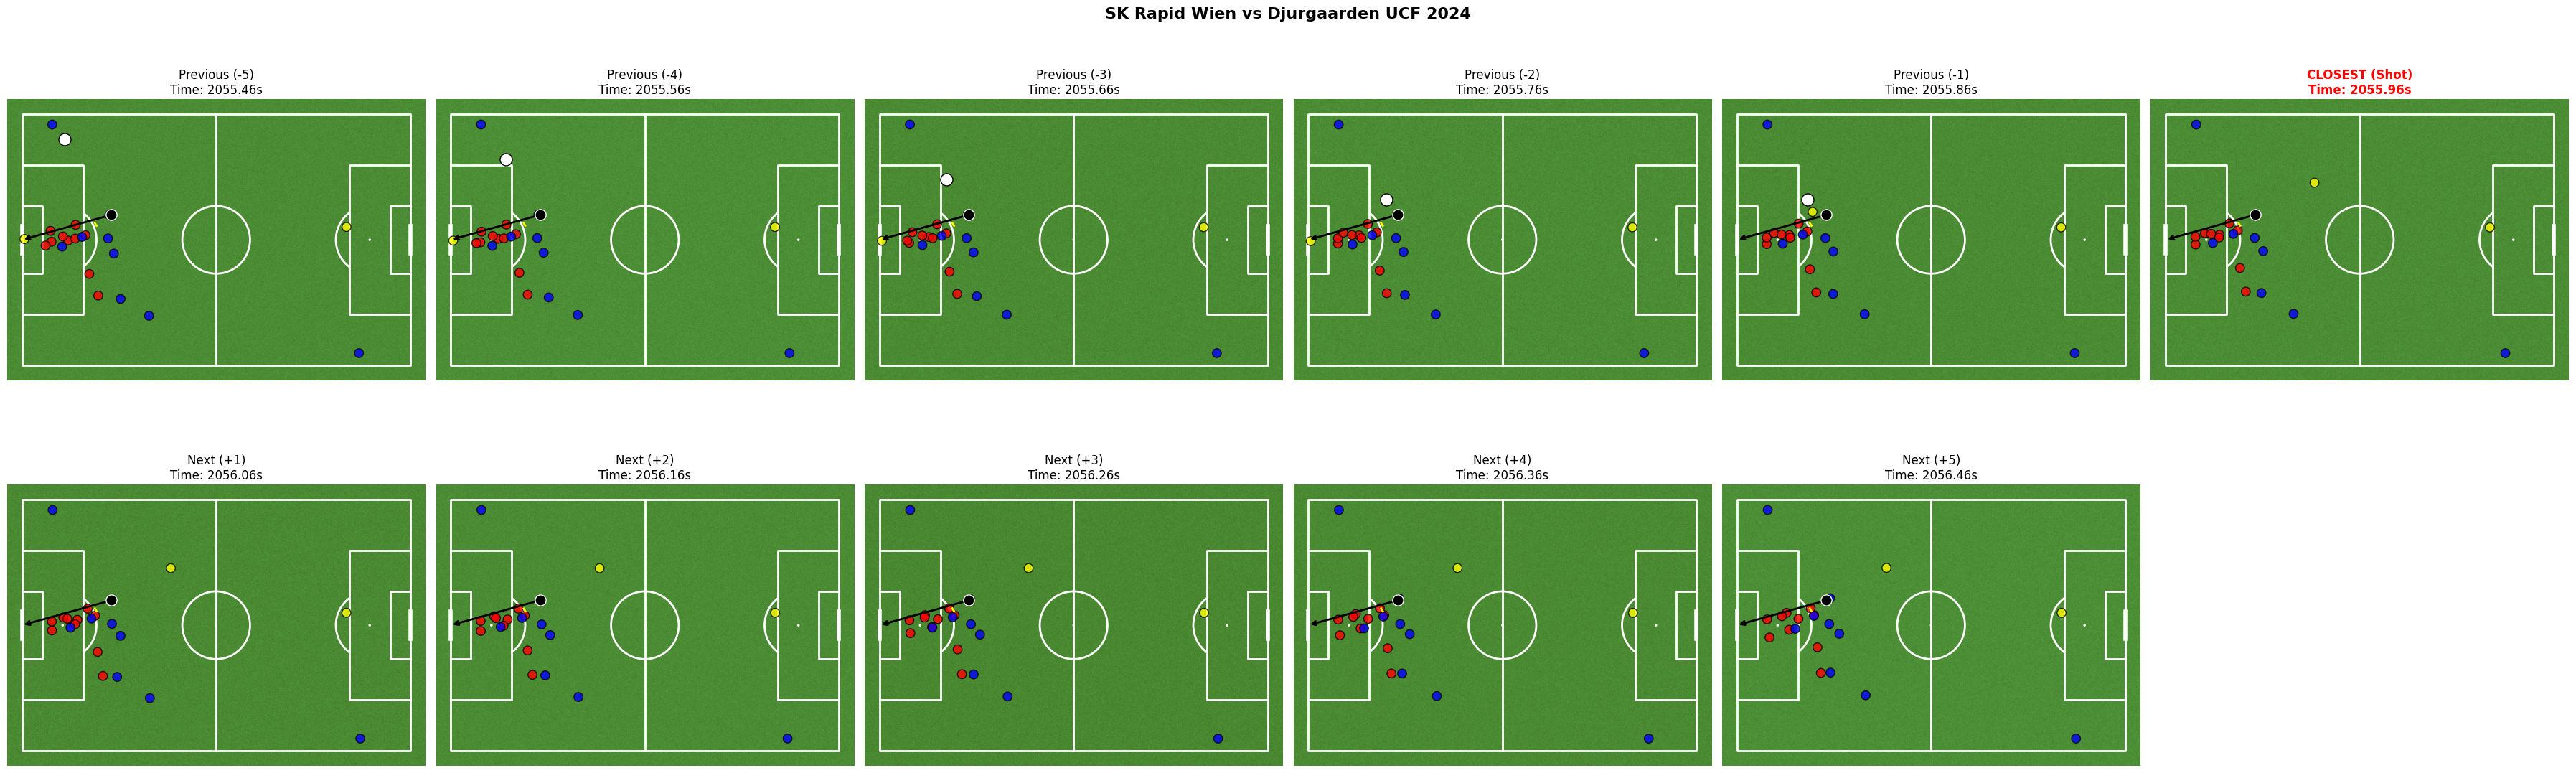

In [222]:
plot_all_frames_for_shot(shots.loc[5])


In [32]:
shots[shots.isnull()].head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal,closest_frame,previous_frames,next_frames,match_info,R,goal_angle,DDI
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
